In [1]:
%load_ext autoreload
%autoreload 2

import os, sys 
sys.path.append("../models")
sys.path.append("../models/src_invariant")
sys.path.append("../models/src_plotting")
# !pip install qutip
from src_invariant.load_all import *
from src_plotting.load_all import *
from qutip import *
import numpy as np
import h5py
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from tqdm import tqdm

In [ ]:
params = {
    'time': None,
    'steps': None,
    'base_coupling': None,
    'system_e_levels': None,
    'system_starts': None,
    'photon_starts': [0],
    'photon_freqs': [1],
    'photon_max_nums': [40],
    'spatial': False,
    'couplings': None,
    'model': None,
    'descr': ""
}

chain_length = 1
params['system_e_levels'] = np.array([[0, 1]])

In [2]:
# In Resoluiton of Gauge Ambiguities

# Gauge Invariant Dipole Model
# Fig 1a 

mini = 0
maxi = 3
step = 0.01
eigenstates = 10
# coupling corresponds to eta in the paper

params['model'] = 'invariant_dipole_minus'
systems_dipole_minus = get_hamiltonians(params, chain_length, mini , maxi, step)
# plot_energies(systems, [i for i in range(7)], min, max, step, xlabel = "Coupling Strength (eta)")
plot_energies(systems_dipole_minus, [i for i in range(10)], mini, maxi, step, 
              omega=params['photon_freqs'][0], norm_state = 0, xlabel = "Coupling Strength (eta)", model="Invariant Dipole")

params['model'] = 'invariant_dipole_plus'
systems_dipole_plus = get_hamiltonians(params, chain_length, mini , maxi, step)
# plot_energies(systems, [i for i in range(7)], min, max, step, xlabel = "Coupling Strength (eta)")
# plot_energies(systems_dipole_plus, [i for i in range(eigenstates)], mini, maxi, step, 
#               omega=params['photon_freqs'][0], norm_state = 0, xlabel = "Coupling Strength (eta)", model="Invariant Dipole")

params['model'] = 'invariant_dipole_pzw'
systems_dipole_pzw = get_hamiltonians(params, chain_length, mini , maxi, step)
# plot_energies(systems, [i for i in range(7)], min, max, step, xlabel = "Coupling Strength (eta)")
# plot_energies(systems_dipole_plus, [i for i in range(eigenstates)], mini, maxi, step, 
#               omega=params['photon_freqs'][0], norm_state = 0, xlabel = "Coupling Strength (eta)", model="Invariant Dipole")

# # Gauge Invariant Coulomb Model
params['model'] = 'invariant_coulomb'
systems_coulomb = get_hamiltonians(params, chain_length, mini , maxi, step)
# # plot_energies(systems, [i for i in range(7)], min, max, step, xlabel = "Coupling Strength (eta)")
# plot_energies(systems_coulomb, [i for i in range(eigenstates)], mini, maxi, step, 
#               omega=params['photon_freqs'][0], norm_state = 0, xlabel = "Coupling Strength (eta)", model="Invariant Coulomb")

plot_compare([systems_dipole_plus, systems_coulomb], 
              [i for i in range(eigenstates)], mini, maxi, step, models_s=["Dipole_Gauge", "Coulomb_Gauge"],
              omega=params['photon_freqs'][0], norm_state = 0, xlabel = "Coupling Strength (eta)")

NameError: name 'params' is not defined

In [12]:
# test to check pzw transformation method for dipole gauge
arr = 1
self = systems_dipole_pzw[arr]
mode = 0
ann_cav = tensor(*[qeye(self.cavity.dims[m]) if mode != m
                                    else destroy(self.cavity.dims[mode])
                                    for m in range(self.cavity.nmodes)], self.mp_systems.identity)
shifted = self.gen_ann_shift(ann_cav)
pzw = self.gen_pzw()
num_op = ann_cav.dag() * ann_cav

# print(np.round(shifted.full(), 3) == np.round((pzw * ann_cav * pzw.dag()).full(), 3))
# print(np.round((shifted.dag() * shifted).full(), 4) == np.round((pzw * num_op * pzw.dag()).full(), 4))

100%|██████████| 300/300 [00:01<00:00, 192.55it/s]


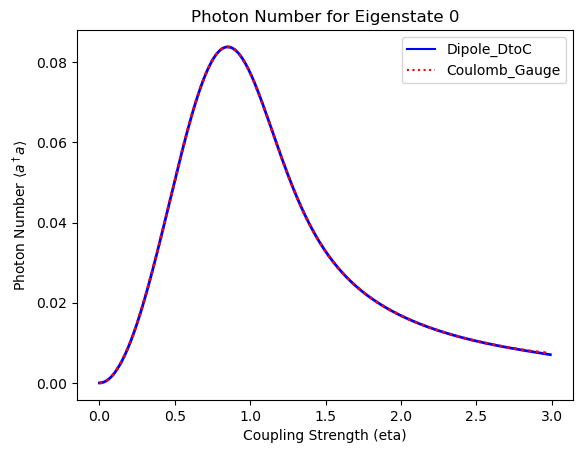

100%|██████████| 300/300 [00:01<00:00, 195.06it/s]


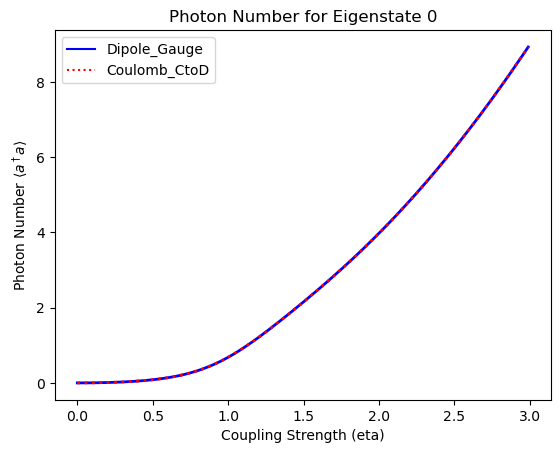

In [5]:
# this is the picture that matches with the resolution paper figure

# plot_aa(systems_dipole_minus, 0, mini, maxi, step, 
#         xlabel = "Coupling (eta)", title = "Photon Number for Ground State, Dipole Invariant -")
# plot_aa(systems_dipole_plus, 0, mini, maxi, step,
#         xlabel = "Coupling (eta)", title = "Photon Number for Ground State, Dipole Invariant +")
# plot_aa(systems_dipole_pzw, 0, mini, maxi, step,
#         xlabel = "Coupling (eta)", title = "Photon Number for Ground State, Dipole Invariant PZW")
# plot_aa(systems_coulomb, 0, mini, maxi, step,
#         xlabel = "Coupling (eta)", title = "Photon Number for Ground State, Coulomb Invariant")

plot_compare([systems_dipole_pzw, systems_coulomb],
              [0], mini, maxi, step, xlabel = "Coupling Strength (eta)", operator="pn", 
             models_s=["Dipole_DtoC", "Coulomb_Gauge"])

plot_compare([systems_dipole_pzw, systems_coulomb],
              [0], mini, maxi, step, xlabel = "Coupling Strength (eta)", operator="pn", 
             models_s=["Dipole_Gauge", "Coulomb_CtoD"])

In [11]:
op_list = [[[0], [0]], [[1], [0]], [[1], [1]], [[0], [1]]]

In [45]:
# check that the eigenstates in dipole gauge with transform are same as coulomb gauge

# arr = 30
# state = 2
# eigenE_plus, eigenV_plus = systems_dipole_plus[arr].total_hamiltonian.eigenstates()
# eigenE_test, eigenV_test = systems_dipole_test[arr].total_hamiltonian.eigenstates()
# eigenE_col, eigenV_col = systems_coulomb[arr].total_hamiltonian.eigenstates()

# print(eigenE_plus == eigenE_test)
# print(eigenV_plus == eigenV_test)
# for ex_op in op_list:
#     print(ex_op)
#     print(expect(systems_dipole_plus[arr].gen_joint_operator(ex_op[0], ex_op[1]), eigenV_plus[state]))
#     print(expect(systems_dipole_test[arr].gen_joint_operator(ex_op[0], ex_op[1]), eigenV_test[state]))
#     print(expect(systems_coulomb[arr].gen_joint_operator(ex_op[0], ex_op[1]), eigenV_col[state]))

100%|██████████| 300/300 [00:00<00:00, 1235.45it/s]


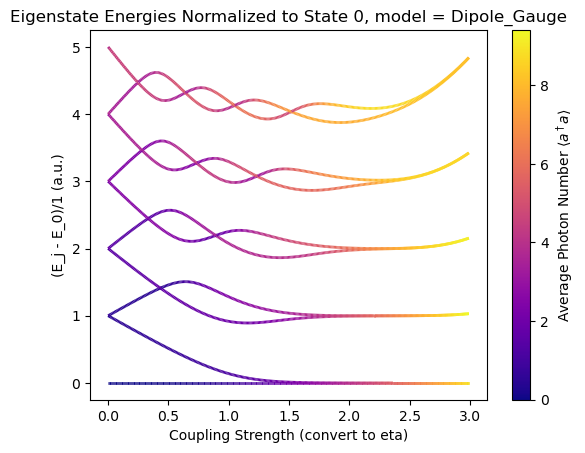

100%|██████████| 300/300 [00:00<00:00, 767.48it/s]


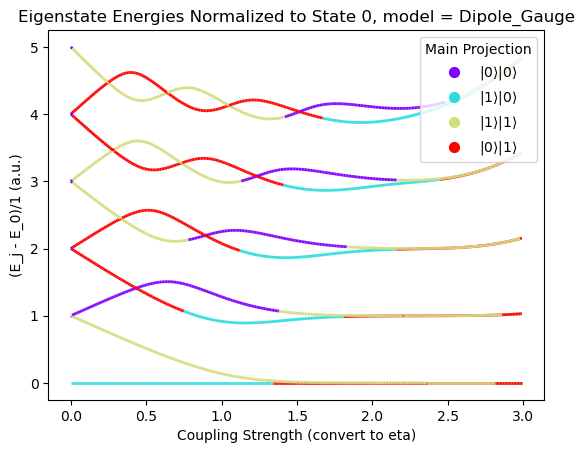

In [49]:
plot_polaritons(systems_dipole_plus, [i for i in range(eigenstates)], mini, maxi, step, 
              omega=1, norm_state = 0,
                xlabel = "Coupling Strength (convert to eta)", model="Dipole_Gauge", cmap='plasma')

plot_domstate(systems_dipole_plus, [i for i in range(eigenstates)], mini, maxi, step, 
              omega=1, norm_state = 0, op_list=op_list,
                 xlabel = "Coupling Strength (convert to eta)", model="Dipole_Gauge", cmap='rainbow')

100%|██████████| 300/300 [00:01<00:00, 290.51it/s]


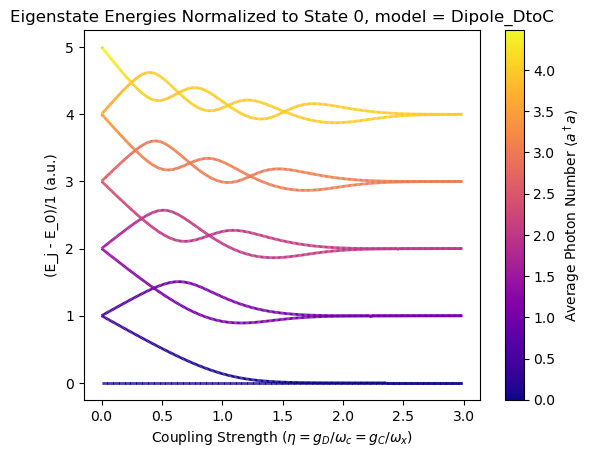

100%|██████████| 300/300 [00:01<00:00, 226.70it/s]


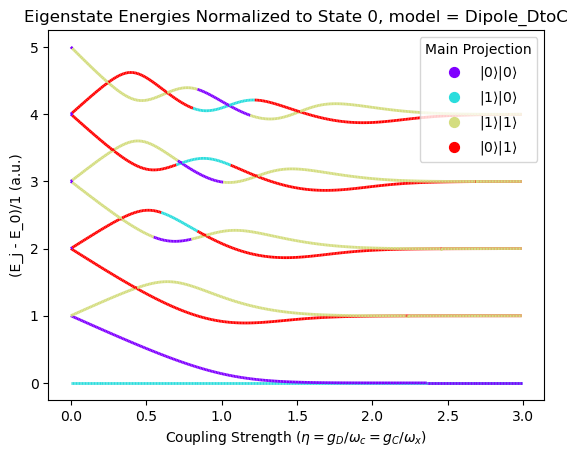

In [14]:
plot_polaritons(systems_dipole_pzw, [i for i in range(eigenstates)], mini, maxi, step, 
              omega=1, norm_state = 0,
                xlabel = "Coupling Strength ($\eta = g_D/\omega_c = g_C/\omega_x$)", model="Dipole_DtoC", cmap='plasma')

plot_domstate(systems_dipole_pzw, [i for i in range(eigenstates)], mini, maxi, step, 
              omega=1, norm_state = 0, op_list=op_list,
                 xlabel = "Coupling Strength ($\eta = g_D/\omega_c = g_C/\omega_x$)", model="Dipole_DtoC", cmap='rainbow')

100%|██████████| 300/300 [00:00<00:00, 555.45it/s]


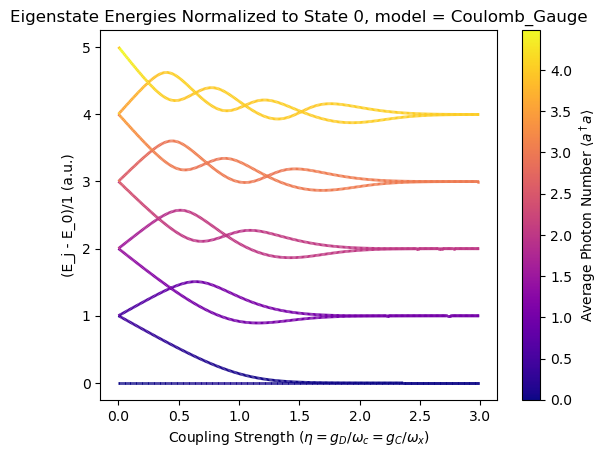

100%|██████████| 300/300 [00:00<00:00, 464.92it/s]


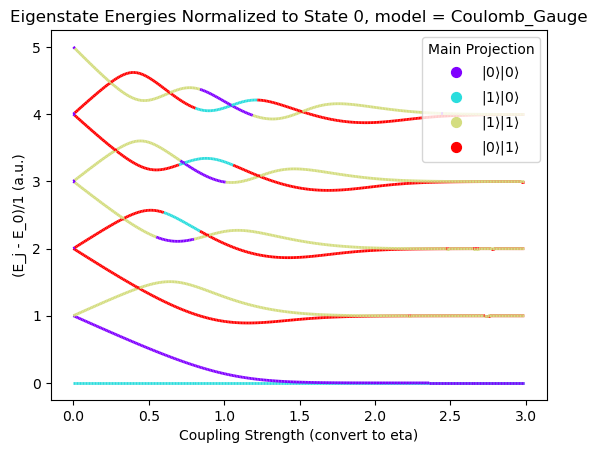

In [13]:
plot_polaritons(systems_coulomb, [i for i in range(eigenstates)], mini, maxi, step, 
              omega=1, norm_state = 0, 
                xlabel = "Coupling Strength ($\eta = g_D/\omega_c = g_C/\omega_x$)", model="Coulomb_Gauge", cmap='plasma')

plot_domstate(systems_coulomb, [i for i in range(eigenstates)], mini, maxi, step, 
              omega=1, norm_state = 0, op_list=op_list,
                 xlabel = "Coupling Strength (convert to eta)", model="Coulomb_Gauge", cmap='rainbow')

100%|██████████| 300/300 [00:00<00:00, 1003.42it/s]


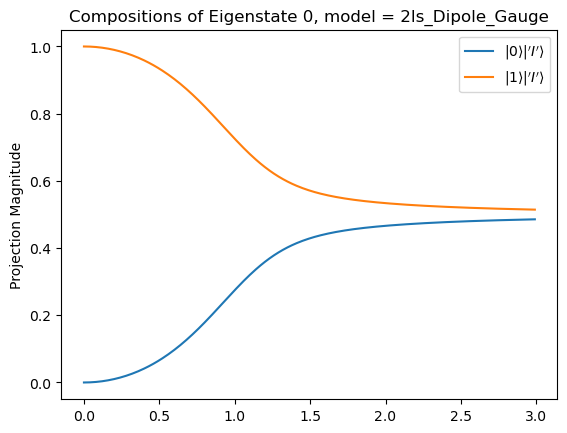

100%|██████████| 300/300 [00:00<00:00, 478.74it/s]


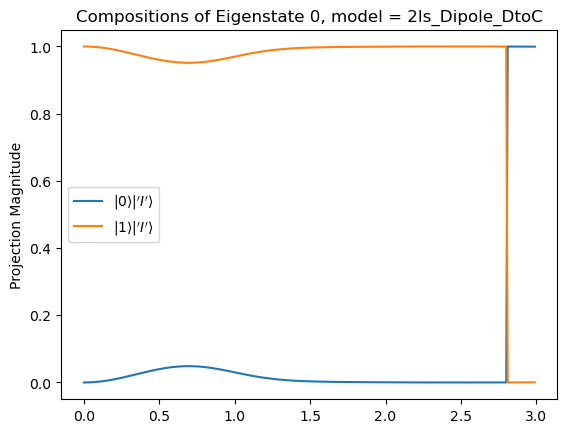

In [57]:
state = 0
comps = [[[0],["I"]], [[1],["I"]]]
comp_labels = ["Ground", "First", "Second"]
plot_state_comp(systems_dipole_plus, state, comps, mini, maxi, step, xlabel="", model="2ls_Dipole_Gauge")
plot_state_comp(systems_dipole_plus, state, comps, mini, maxi, step, xlabel="", model="2ls_Dipole_DtoC")

100%|██████████| 300/300 [00:00<00:00, 993.13it/s] 


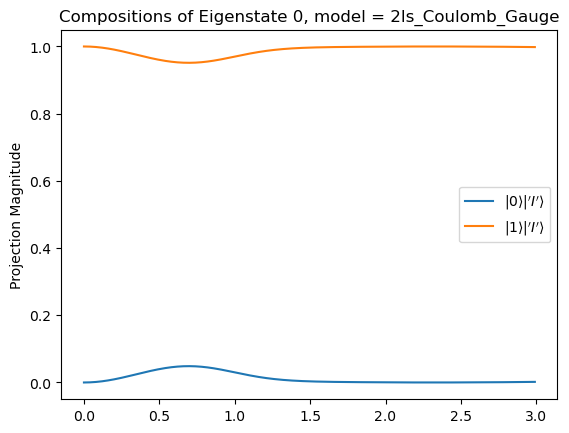

In [56]:
state = 0
comps = [[[0],["I"]], [[1],["I"]]]
comp_labels = ["Ground", "First", "Second"]
plot_state_comp(systems_coulomb, state, comps, mini, maxi, step, xlabel="", model="2ls_Coulomb_Gauge")